# Alzheimer's Disease Detection with a Simple ANN

This notebook uses a fully-connected Artificial Neural Network (ANN) instead of ResNet50.  
It uses:

- patient-level train/validation/test splits
- Simple ANN trained from scratch (no pretrained weights)
- Reduced image size (64×64) to keep the flattened input manageable
- Standard /255 pixel normalisation instead of ImageNet mean-subtraction
- class weights for imbalance
- a single sparse-label training path to avoid label/loss mismatch
- test-time evaluation with confusion matrix and classification report


In [16]:
# CHANGES vs ResNet version:
#   - Removed: ResNet50, preprocess_input imports (no longer needed)
#   - IMG_SIZE reduced from (128,128) to (64,64):
#       128x128x3 = 49,152 inputs -> too large for a dense layer
#       64x64x3   = 12,288 inputs -> manageable for ANN

import os
import re
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import display
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm
from scipy.stats import skew

from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support,
    roc_auc_score,
)

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

from matplotlib.colors import LogNorm

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Config
DATA_ROOT    = "/kaggle/input/imagesoasis"
DATASET_DIR  = os.path.join(DATA_ROOT, "Data")
IMG_SIZE     = (64, 64)   # CHANGED: was (128,128) — 64x64x3=12,288 inputs is much more ANN-friendly
BATCH_SIZE   = 32
NUM_CLASSES  = 3

CLASS_LABELS = ['Non Demented', 'Very Mild Dementia', 'Mild/Moderate Dementia']
LABEL_MAP = {
    'Non Demented':      0,
    'Very mild Dementia': 1,
    'Mild Dementia':      2,
    'Moderate Dementia':  2,
}

AUTOTUNE = tf.data.AUTOTUNE
print("Imports and configuration ready.")

Imports and configuration ready.


## 1) Collect image paths and build a reference dataframe

In [17]:
def get_info_from_filename(filename: str):
    pattern = re.compile(r'OAS1_(\d+)_MR(\d+)_mpr-(\d+)_(\d+)\.jpg$')
    match = pattern.match(filename)
    if match is None:
        return None
    patient_id, mr_id, scan_id, layer_id = match.groups()
    return int(patient_id), int(mr_id), int(scan_id), int(layer_id)

def create_ref_df(dataset_path: str) -> pd.DataFrame:
    paths, labels = [], []
    patient_ids, mr_ids, scan_ids, layer_ids = [], [], [], []

    for folder in sorted(os.listdir(dataset_path)):
        folder_path = os.path.join(dataset_path, folder)
        if not os.path.isdir(folder_path):
            continue
        for file in sorted(os.listdir(folder_path)):
            parsed = get_info_from_filename(file)
            if parsed is None:
                continue
            patient_id, mr_id, scan_id, layer_id = parsed
            paths.append(os.path.join(folder_path, file))
            labels.append(folder)
            patient_ids.append(patient_id)
            mr_ids.append(mr_id)
            scan_ids.append(scan_id)
            layer_ids.append(layer_id)

    return pd.DataFrame({
        'path':       paths,
        'label':      labels,
        'patient_id': patient_ids,
        'mr_id':      mr_ids,
        'scan_id':    scan_ids,
        'layer_id':   layer_ids,
    })

ref_df = create_ref_df(DATASET_DIR)
print("Shape:", ref_df.shape)
display(ref_df.head())
print(ref_df['label'].value_counts())

Shape: (86437, 6)


,path,label,patient_id,mr_id,scan_id,layer_id
0,/kaggle/input/imagesoasis/Data/Mild Dementia/O...,Mild Dementia,28,1,1,100
1,/kaggle/input/imagesoasis/Data/Mild Dementia/O...,Mild Dementia,28,1,1,101
2,/kaggle/input/imagesoasis/Data/Mild Dementia/O...,Mild Dementia,28,1,1,102
3,/kaggle/input/imagesoasis/Data/Mild Dementia/O...,Mild Dementia,28,1,1,103
4,/kaggle/input/imagesoasis/Data/Mild Dementia/O...,Mild Dementia,28,1,1,104


label
Non Demented          67222
Very mild Dementia    13725
Mild Dementia          5002
Moderate Dementia       488
Name: count, dtype: int64


## 2) Quick visual check

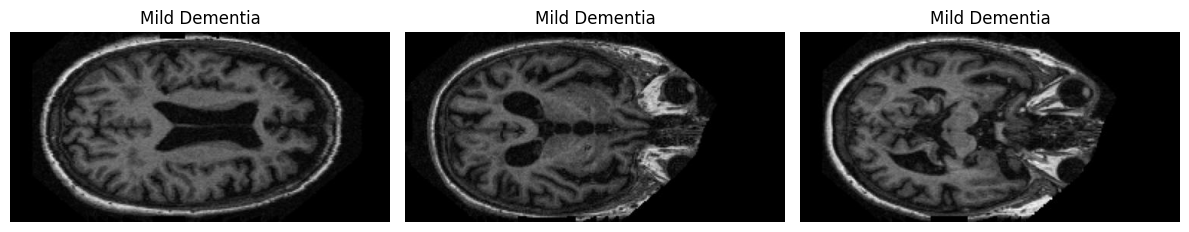

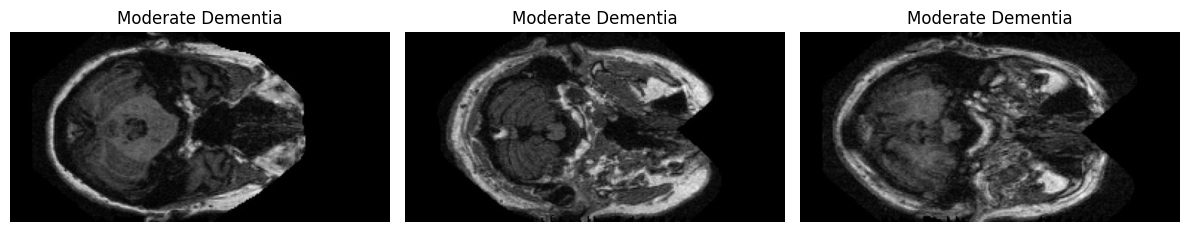

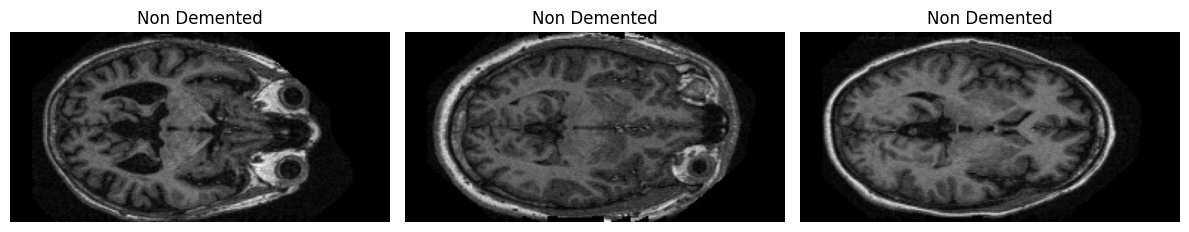

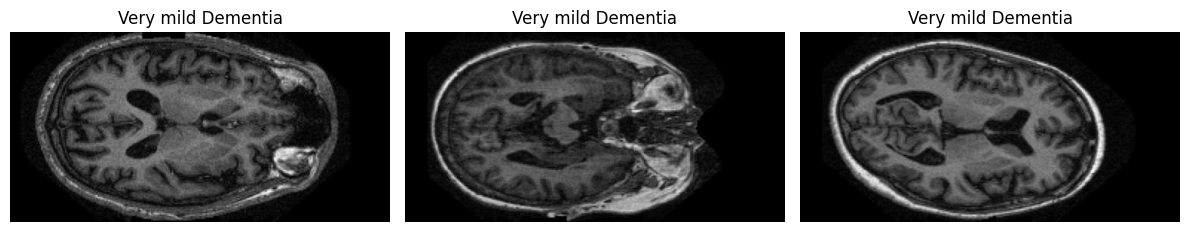

In [18]:
def show_samples(df, n=3, seed=42):
    sample = df.sample(n=min(n, len(df)), random_state=seed)
    plt.figure(figsize=(12, 4))
    for i, (_, row) in enumerate(sample.iterrows(), start=1):
        img = Image.open(row['path']).convert('RGB')
        plt.subplot(1, len(sample), i)
        plt.imshow(img)
        plt.title(row['label'])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

for label in ref_df['label'].unique():
    show_samples(ref_df[ref_df['label'] == label], n=3)

## 3) Patient-level train/validation/test split

In [19]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
for train_idx, test_idx in gss.split(ref_df, groups=ref_df['patient_id']):
    train_df = ref_df.iloc[train_idx].reset_index(drop=True)
    test_df  = ref_df.iloc[test_idx].reset_index(drop=True)

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
for train_idx, val_idx in gss_val.split(train_df, groups=train_df['patient_id']):
    train_final = train_df.iloc[train_idx].reset_index(drop=True)
    val_df      = train_df.iloc[val_idx].reset_index(drop=True)

print("Train scans:", len(train_final))
print("Val scans  :", len(val_df))
print("Test scans :", len(test_df))

print("\nPatient overlap checks")
print("Train ∩ Val :", len(set(train_final['patient_id']) & set(val_df['patient_id'])))
print("Train ∩ Test:", len(set(train_final['patient_id']) & set(test_df['patient_id'])))
print("Val   ∩ Test:", len(set(val_df['patient_id'])  & set(test_df['patient_id'])))

Train scans: 54412
Val scans  : 13481
Test scans : 18544

Patient overlap checks
Train ∩ Val : 0
Train ∩ Test: 0
Val   ∩ Test: 0


In [20]:
def apply_label_map(df):
    df = df.copy()
    df['label_int'] = df['label'].map(LABEL_MAP)
    if df['label_int'].isna().any():
        missing = sorted(df.loc[df['label_int'].isna(), 'label'].unique())
        raise ValueError(f"Unmapped labels found: {missing}")
    df['label_int'] = df['label_int'].astype(int)
    return df

train_final = apply_label_map(train_final)
val_df      = apply_label_map(val_df)
test_df     = apply_label_map(test_df)

print("Merged class counts (train):")
print(train_final['label_int'].value_counts().sort_index())
print("\nMerged class counts (val):")
print(val_df['label_int'].value_counts().sort_index())
print("\nMerged class counts (test):")
print(test_df['label_int'].value_counts().sort_index())

Merged class counts (train):
label_int
0    41236
1     9150
2     4026
Name: count, dtype: int64

Merged class counts (val):
label_int
0    10858
1     2379
2      244
Name: count, dtype: int64

Merged class counts (test):
label_int
0    15128
1     2196
2     1220
Name: count, dtype: int64


## 4) Dataset statistics and class weights

In [21]:
def compute_sample_image_stats(df, samples_per_class=25, seed=42):
    sample_parts = []
    for label, group in df.groupby('label'):
        n = min(samples_per_class, len(group))
        sample_parts.append(group.sample(n=n, random_state=seed))
    sample_df = pd.concat(sample_parts).reset_index(drop=True)

    means, stds, widths, heights, skewnesses = [], [], [], [], []
    for _, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
        image = np.array(Image.open(row['path']).convert('L'))
        means.append(np.mean(image))
        stds.append(np.std(image))
        heights.append(image.shape[0])
        widths.append(image.shape[1])
        image_hist = np.histogram(image.flatten(), bins=256)[0]
        skewnesses.append(skew(image_hist))

    return pd.DataFrame({
        'mean':   means,
        'std':    stds,
        'width':  widths,
        'height': heights,
        'skew':   skewnesses,
        'label':  sample_df['label'].values,
        'path':   sample_df['path'].values,
    })

image_stats = compute_sample_image_stats(ref_df, samples_per_class=10)
print(image_stats.head())

100%|██████████| 40/40 [00:00<00:00, 95.83it/s]

        mean        std  width  height       skew          label  \
0  41.990318  42.193547    496     248  14.428389  Mild Dementia   
1  35.633861  40.534605    496     248  15.421742  Mild Dementia   
2  39.810029  46.164847    496     248  15.568597  Mild Dementia   
3  43.503886  45.526086    496     248  15.215670  Mild Dementia   
4  39.221246  39.372820    496     248  12.677983  Mild Dementia   

                                                path  
0  /kaggle/input/imagesoasis/Data/Mild Dementia/O...  
1  /kaggle/input/imagesoasis/Data/Mild Dementia/O...  
2  /kaggle/input/imagesoasis/Data/Mild Dementia/O...  
3  /kaggle/input/imagesoasis/Data/Mild Dementia/O...  
4  /kaggle/input/imagesoasis/Data/Mild Dementia/O...  


In [22]:
y_train_all = train_final['label_int'].values
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=y_train_all
)
class_weight_dict = dict(enumerate(class_weights_arr))
print("Class weights:", class_weight_dict)

Class weights: {0: 0.43984220907297833, 1: 1.9822222222222223, 2: 4.505050505050505}


## 5) Build tf.data pipelines

**Key changes from ResNet version:**
- `preprocess_input` (ImageNet mean-subtraction) removed — replaced with `/255.0` normalisation.
  ResNet's preprocessing maps pixels to roughly [-1, 1] around ImageNet stats;
  an ANN trained from scratch expects plain [0, 1] floats.
- `IMG_SIZE` is now (64, 64), so images are resized to that smaller resolution.
- Augmentation kept as-is; it operates on raw pixel values before normalisation,
  which is correct regardless of the model.

In [23]:
# CHANGED: removed RandomBrightness — it requires TF 2.9+ and has no benefit
#          specific to ANN; kept the rest of the standard augmentations.
augmentation_layer = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
], name='augmentation')

def load_image(path):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)   # now 64x64
    image = tf.cast(image, tf.float32)
    return image

def make_dataset(df, label_col, one_hot=False, augment=False, shuffle=False):
    paths  = tf.constant(df['path'].values,      dtype=tf.string)
    labels = tf.constant(df[label_col].values,   dtype=tf.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED, reshuffle_each_iteration=True)

    def _load(path, label):
        image = load_image(path)
        if augment:
            image = augmentation_layer(image, training=True)
        # CHANGED: was preprocess_input(image) — ImageNet-specific, not valid for ANN
        image = image / 255.0   # simple [0,1] normalisation
        if one_hot:
            label = tf.one_hot(label, NUM_CLASSES)
        return image, label

    ds = ds.map(_load, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_final, 'label_int', one_hot=False, augment=True,  shuffle=True)
val_ds   = make_dataset(val_df,      'label_int', one_hot=False, augment=False, shuffle=False)
test_ds  = make_dataset(test_df,     'label_int', one_hot=False, augment=False, shuffle=False)

y_test_int    = test_df['label_int'].values
y_test_onehot = to_categorical(y_test_int, NUM_CLASSES)

print("Datasets ready.")
print("Train batches:", len(train_ds))
print("Val batches  :", len(val_ds))
print("Test batches :", len(test_ds))

Datasets ready.
Train batches: 1701
Val batches  : 422
Test batches : 580


## 6) Build the ANN model

**Changes from ResNet version:**
- Entire `build_resnet50_model` replaced with `build_ann_model`.
- No pretrained base — all weights are initialised randomly and learned from scratch.
- `Flatten` converts the 64×64×3 image into a 12,288-dimensional vector.
- Three Dense blocks with BatchNorm + Dropout replace the convolutional backbone.
- `GlobalAveragePooling2D` removed — not applicable to a flat ANN.
- `training=False` argument on the base model call removed — no base model exists.
- L2 regularisation added to Dense layers to compensate for the lack of pretrained priors.

In [24]:
from tensorflow.keras.regularizers import l2

def build_ann_model():
    """
    Simple fully-connected ANN for Alzheimer's classification.
    Input: 64x64x3 image  ->  Flatten  ->  Dense stack  ->  Softmax
    """
    inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3), name='input')

    # Flatten: 64*64*3 = 12,288 neurons
    x = layers.Flatten(name='flatten')(inputs)

    # Block 1
    x = layers.Dense(512, activation='relu', kernel_regularizer=l2(1e-4), name='dense_1')(x)
    x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.Dropout(0.4, name='drop_1')(x)

    # Block 2
    x = layers.Dense(256, activation='relu', kernel_regularizer=l2(1e-4), name='dense_2')(x)
    x = layers.BatchNormalization(name='bn_2')(x)
    x = layers.Dropout(0.4, name='drop_2')(x)

    # Block 3
    x = layers.Dense(128, activation='relu', kernel_regularizer=l2(1e-4), name='dense_3')(x)
    x = layers.BatchNormalization(name='bn_3')(x)
    x = layers.Dropout(0.3, name='drop_3')(x)

    # Output
    outputs = layers.Dense(NUM_CLASSES, activation='softmax', name='output')(x)

    model = models.Model(inputs, outputs, name='ANN_Alzheimers')
    return model

model = build_ann_model()
model.summary()

Model: "ANN_Alzheimers"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (InputLayer)          [(None, 64, 64, 3)]       0         
                                                                 
 flatten (Flatten)           (None, 12288)             0         
                                                                 
 dense_1 (Dense)             (None, 512)               6291968   
                                                                 
 bn_1 (BatchNormalization)   (None, 512)               2048      
                                                                 
 drop_1 (Dropout)            (None, 512)               0         
                                                                 
 dense_2 (Dense)             (None, 256)               131328    
                                                                 
 bn_2 (BatchNormalization)   (None, 256)            

## 7) Compile and train the model

**Changes from ResNet version:**
- Learning rate raised from `1e-4` → `3e-4`: training from scratch benefits from a
  slightly higher initial LR since there are no pretrained weights to preserve.
- Epochs increased from 20 → 50: an ANN trained from scratch needs more passes
  to converge without the head-start of ImageNet pretraining.
- EarlyStopping patience raised from 5 → 10 to give the model enough runway.
- ReduceLROnPlateau patience raised from 3 → 5 for the same reason.

In [25]:
model.compile(
    optimizer=Adam(learning_rate=3e-4),   # CHANGED: was 1e-4 (ResNet fine-tuning rate)
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,              # CHANGED: was 5 — ANN needs more epochs to settle
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,               # CHANGED: was 3
    min_lr=1e-7,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,                # CHANGED: was 20 — no pretrained weights, needs more epochs
    class_weight=class_weight_dict,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/50
1701/1701 [==============================] - 189s 109ms/step - loss: 1.3018 - accuracy: 0.4760 - val_loss: 1.3192 - val_accuracy: 0.3702 - lr: 3.0000e-04
Epoch 2/50
1701/1701 [==============================] - 63s 37ms/step - loss: 1.0882 - accuracy: 0.5391 - val_loss: 1.0540 - val_accuracy: 0.5270 - lr: 3.0000e-04
Epoch 3/50
1701/1701 [==============================] - 64s 37ms/step - loss: 1.0227 - accuracy: 0.5678 - val_loss: 0.8156 - val_accuracy: 0.6588 - lr: 3.0000e-04
Epoch 4/50
1701/1701 [==============================] - 63s 37ms/step - loss: 0.9864 - accuracy: 0.5802 - val_loss: 0.9801 - val_accuracy: 0.5703 - lr: 3.0000e-04
Epoch 5/50
1701/1701 [==============================] - 63s 37ms/step - loss: 0.9556 - accuracy: 0.5923 - val_loss: 0.8645 - val_accuracy: 0.6373 - lr: 3.0000e-04
Epoch 6/50
1701/1701 [==============================] - 62s 37ms/step - loss: 0.9297 - accuracy: 0.6005 - val_loss: 0.9873 - val_accuracy: 0.5638 - lr: 3.0000e-04
Epoch 7/50
1701/1701

## 7b) Training curves

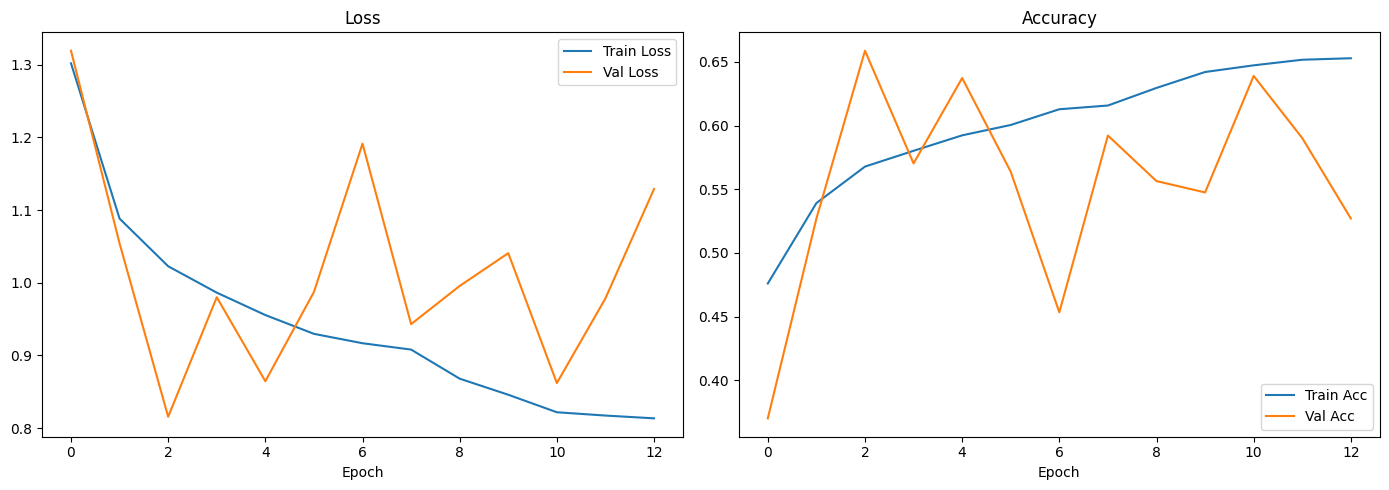

In [26]:
# Plot training history — useful for diagnosing overfitting in an ANN
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8) Evaluate on the test set

In [27]:
test_loss, test_acc = model.evaluate(test_ds, verbose=2)
print("Test loss    :", test_loss)
print("Test accuracy:", test_acc)

580/580 - 48s - loss: 0.7712 - accuracy: 0.7490 - 48s/epoch - 83ms/step
Test loss    : 0.7712318897247314
Test accuracy: 0.7490293383598328


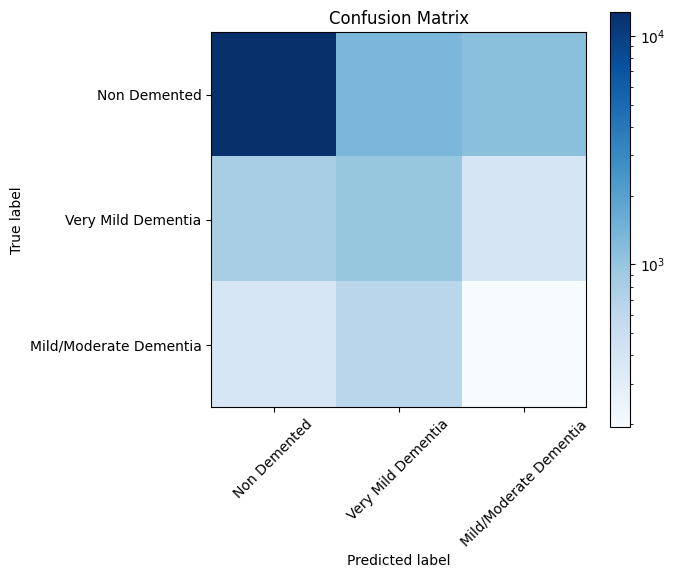

                        precision    recall  f1-score   support

          Non Demented     0.9144    0.8393    0.8752     15128
    Very Mild Dementia     0.3378    0.4549    0.3877      2196
Mild/Moderate Dementia     0.1141    0.1590    0.1328      1220

              accuracy                         0.7490     18544
             macro avg     0.4554    0.4844    0.4653     18544
          weighted avg     0.7934    0.7490    0.7687     18544



In [28]:
y_probs = model.predict(test_ds, verbose=0)
y_pred  = np.argmax(y_probs, axis=1)

cm = confusion_matrix(y_test_int, y_pred, labels=[0, 1, 2])

plt.figure(figsize=(7, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues, norm=LogNorm())
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(NUM_CLASSES)
plt.xticks(tick_marks, CLASS_LABELS, rotation=45)
plt.yticks(tick_marks, CLASS_LABELS)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

print(classification_report(y_test_int, y_pred, target_names=CLASS_LABELS, digits=4))

In [29]:
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test_int, y_pred, average=None, labels=[0, 1, 2], zero_division=0
)

for i, (p, r, f) in enumerate(zip(precision, recall, f1)):
    print(f"Class {i} ({CLASS_LABELS[i]}): Precision={p:.4f}  Recall={r:.4f}  F1={f:.4f}")

micro_p, micro_r, micro_f1, _ = precision_recall_fscore_support(
    y_test_int, y_pred, average='micro', zero_division=0
)
print(f"Micro-average: Precision={micro_p:.4f}  Recall={micro_r:.4f}  F1={micro_f1:.4f}")

Class 0 (Non Demented): Precision=0.9144  Recall=0.8393  F1=0.8752
Class 1 (Very Mild Dementia): Precision=0.3378  Recall=0.4549  F1=0.3877
Class 2 (Mild/Moderate Dementia): Precision=0.1141  Recall=0.1590  F1=0.1328
Micro-average: Precision=0.7490  Recall=0.7490  F1=0.7490


In [30]:
try:
    roc_auc_per_class = roc_auc_score(y_test_onehot, y_probs, average=None)
    for i, auc_score in enumerate(np.atleast_1d(roc_auc_per_class)):
        print(f"Class {i} ({CLASS_LABELS[i]}): ROC AUC = {auc_score:.4f}")
    roc_auc_micro = roc_auc_score(y_test_onehot, y_probs, average='micro')
    print("Micro-average ROC AUC:", round(roc_auc_micro, 4))
except ValueError as e:
    print("ROC AUC could not be computed:", e)

Class 0 (Non Demented): ROC AUC = 0.8099
Class 1 (Very Mild Dementia): ROC AUC = 0.7603
Class 2 (Mild/Moderate Dementia): ROC AUC = 0.6843
Micro-average ROC AUC: 0.8879


In [31]:
def scotts_pi(cm):
    total = np.sum(cm)
    if total == 0:
        return np.nan
    p_o       = np.trace(cm) / total
    row_totals = np.sum(cm, axis=1) / total
    col_totals = np.sum(cm, axis=0) / total
    p_e = np.sum(row_totals * col_totals)
    if np.isclose(1 - p_e, 0):
        return np.nan
    return (p_o - p_e) / (1 - p_e)

print("Scott's Pi:", round(scotts_pi(cm), 4))

Scott's Pi: 0.3109


## 9) Leakage and sanity checks

In [32]:
print("Train ∩ Val patient overlap :", len(set(train_final['patient_id']) & set(val_df['patient_id'])))
print("Train ∩ Test patient overlap:", len(set(train_final['patient_id']) & set(test_df['patient_id'])))
print("Val   ∩ Test patient overlap:", len(set(val_df['patient_id'])  & set(test_df['patient_id'])))

print("\nTrain path overlap with test:", len(set(train_final['path']) & set(test_df['path'])))
print("Val path overlap with test  :", len(set(val_df['path'])   & set(test_df['path'])))

Train ∩ Val patient overlap : 0
Train ∩ Test patient overlap: 0
Val   ∩ Test patient overlap: 0

Train path overlap with test: 0
Val path overlap with test  : 0


## 10) Save the trained model

In [33]:
# CHANGED: filename updated to reflect ANN architecture
model.save("alzheimers_ann_final.keras")
print("Model saved as alzheimers_ann_final.keras")

Model saved as alzheimers_ann_final.keras
